In [14]:
import sys

sys.path.append('../')

from signals.cta_momentum_etf import Momentum
import pytz
from datetime import datetime
from performance_metrics.performance import Trading_Strategy
from performance_metrics import price_to_info as pti
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# CTA Momentum using ETF - Strategy Replication

## Introduction
This blog is dedicated to replicate an article that I recently came across. The idea is to create a dynamic trend following portfolio consisting of multiple asset classes by trading a basket of ETFs. **The authors claimed this to be a "CTA proxy" and argued that the strategy can be significantly improved if the short leg from some asset classes is removed. In this blog, I intend to replicate this strategy and see if I can get similar results. In addition, I added another category that proved to be working well in the past 24 months, and removed ones (mostly bonds & commodity) that have lost profitability recently.**

Link to the article: https://quantpedia.com/exploration-of-cta-momentum-strategies-using-etfs/?a=6080

## Trading Universe
The ETFs used in the strategy: <br>
**Stock:** US Equities (**SPY**), Small Cap (**IWM**), Europe/Aus/Far East (**EFA**), Emerging Markets (**EEM**), US Real Estate (**IYR**), US Tech (**QQQ**) <br>
**Bond & FX:** IG Corp (**LQD**), 7-10 Yr Treasury (**IEF**), Inflation Protected Treasury (**TIP**), Euro (**FXE**) <br>
**Commodity:** Gold (**GLD**), Oil (**USO**), DB Commodity Index (**DBC**) <br>

## Strategy Description
For each ticker, perform the following: <br>
- Calculate daily performance
- Aggregate rolling 3 Month, 6 Month, 9 Month, and 12 Month return
- Average the four numbers
- Positive outcome is a long signal, Negative outcome is a short signal (For long only construction, negative outcome is no trade signal)

## Portfolio Construction
All portfolios are constructed using inverse volatility weighting scheme. In the article, the authors used last 20 days realized volatility. In this blog, I used the past one month realized volatility. 

## Rebalancing
Once signal is obtained at the end of each month, hold the position for the entirety of next month. Rebalance is conducted monthly at the last trading day of each month. This reduces the frequency of trades (vs. daily rebalancing), and avoids hefty slippage cost.

## Results

In [15]:
stock_etf = ['SPY', 'IWM', 'EFA', 'EEM', 'QQQ']
bond_fx_etf = ['LQD', 'IEF', 'TIP', 'FXE']
commod_etf = ['GLD', 'USO', 'DBC']

etf_list = stock_etf + bond_fx_etf + commod_etf
print(etf_list)

['SPY', 'IWM', 'EFA', 'EEM', 'QQQ', 'LQD', 'IEF', 'TIP', 'FXE', 'GLD', 'USO', 'DBC']


In [16]:
tz = pytz.timezone('America/New_York')
st = tz.localize(datetime(2006, 1, 1))
et = tz.localize(datetime(2024, 9, 1))

In [17]:
filename = '../yfinance_data/cta_momentum_data_replicate.csv'

### Long-Short
A few observations and conclusions from my replication and the article's analysis: <br>
- Over the same backtesting period, our PnL's shapes look very similar to one another in general, but with different magnitude of cumulative returns and drawdowns. For example, the annualized return of the article is 2.86%, whereas my replication is 3.67%; and the max drawdown of the article is 19.45%, and the replication is 10.41%. <br>
- For each sub portfolio (stocks, bond & fx, commodity), we see different levels of variation in terms of replication comparison. Again, we got all the shapes right (strategy peak and trough around the same time), but the details seem to not be reconciled. <br>
    - For stocks, the article is claiming an overall negative annualized return (-0.63%), which I find it hard to believe. The replication in this blog in fact suggests a positive 3.12% annualized return (with a low sharpe of 0.2). In addition, the article shows around 50% max drawdown, to which the replication suggests "only" 32%.
    - Bonds and Fx sub portfolio is probably the one that I could replicate the most closely in this exercise. We both get very similar drawdown, sharpe, and returns. This sub portfolio seems to be one that does not make a lot of noise most of the time, which fits the risk-reward profile of fixed income vehicles. The only time trend following could potentially contribute largely to the overall portfolio is during an interest rate event environment, which we have seen in 2022.
    - Commod is another one that I got similar but still not perfectly matching results. The article got a sharpe of 0.29 vs. 0.41 in my replication.


In [18]:
cut_off = '2023-02'

In [19]:
momentum_strat = Momentum(trading_universe = etf_list, 
                          start_time = st, 
                          end_time = et, 
                          path = filename)

In [20]:
all_return = pd.DataFrame()
all_return_perf = pd.DataFrame()

for i in [etf_list, stock_etf, bond_fx_etf, commod_etf]:
    temp_return = momentum_strat.get_performance(pti.get_alloc_weight(momentum_strat.get_vol(), i))
    all_return = pd.concat([all_return, temp_return.set_index('date')], axis=1)

    temp_perf = Trading_Strategy(temp_return.loc[temp_return['date']<=cut_off],'Monthly').get_metrics_table()
    all_return_perf = pd.concat([all_return_perf, temp_perf], axis=1)

all_return.columns = ['overall', 'stocks', 'bond_fx', 'commodity']
all_return_perf.columns = ['overall', 'stocks', 'bond_fx', 'commodity']

### Overall Portfolio comparison

========================  =========
           ..              overall
========================  =========
          From             2007-05
           To              2023-02
   Annualized Sharpe       0.64797
   Annualized Sortino      0.9706
 Cumulative Log Return     0.57211
Cumulative Dollar Return   1.77201
       Avg Return          0.00301
        Avg Win            0.01277
        Avg Loss          -0.01163
       Win Ratio             0.6
       Max Winner          0.05467
       Max Loser          -0.04869
      Max Drawdown        -0.10406
 Annualized Volatility     0.05576
   Annualized Return       0.03674
   Annualized Calmar       0.10024
          Skew            -0.11061
        Kurtosis           1.00215
       CVAR(95%)          -0.03452
========================  =========


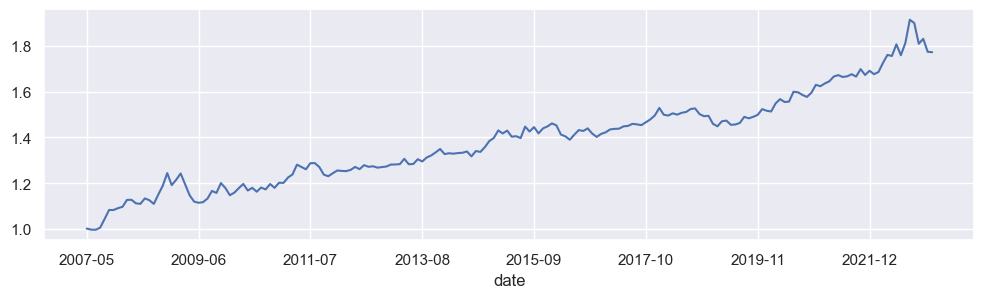

In [28]:
print(tabulate(all_return_perf[['overall']],headers='keys', tablefmt='rst',stralign='center'))

sns.set(font_scale=1)
%matplotlib inline
np.exp(all_return['overall'].cumsum().loc[:cut_off]).plot(figsize = (12,3))
plt.show()

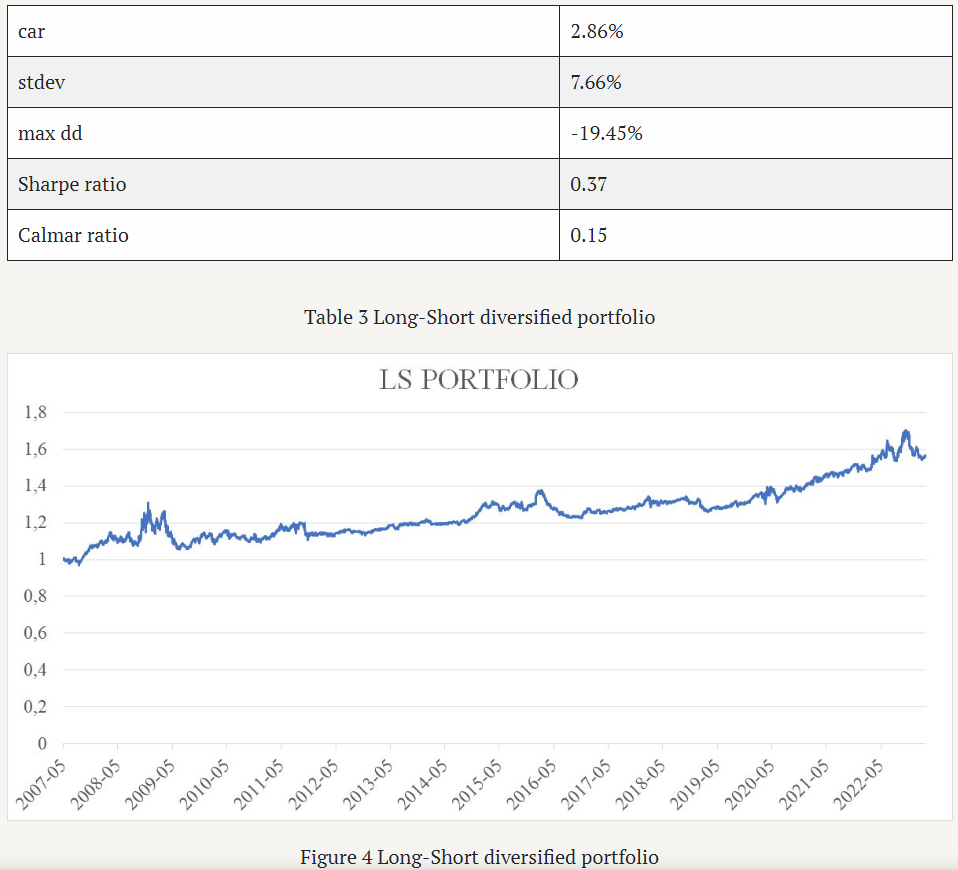

In [22]:
from IPython import display
display.Image('./miscellaneous/cta_long_short_portfolio_quantpedia.png',width=600,height=100)

### Sub-Portfolios Comparison

========================  ========  =========  ===========
           ..              stocks    bond_fx    commodity
========================  ========  =========  ===========
          From            2007-05    2007-05     2007-05
           To             2023-02    2023-02     2023-02
   Annualized Sharpe      0.20619    0.5978      0.40979
   Annualized Sortino     0.29193    0.9079      0.85604
 Cumulative Log Return    0.48672    0.44984     0.9746
Cumulative Dollar Return  1.62697    1.56806     2.65011
       Avg Return         0.00256    0.00237     0.00513
        Avg Win           0.02994    0.01133     0.0358
        Avg Loss          -0.03273  -0.00847    -0.02895
       Win Ratio          0.56316    0.54737     0.52632
       Max Winner         0.21276    0.05127     0.24573
       Max Loser          -0.12091  -0.05685    -0.09277
      Max Drawdown        -0.32493  -0.10221    -0.33622
 Annualized Volatility    0.14909    0.04753     0.15021
   Annualized Return      0.

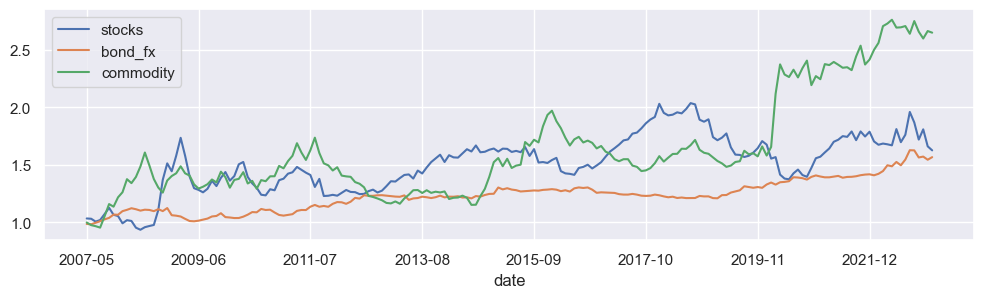

In [29]:
print(tabulate(all_return_perf[[ 'stocks', 'bond_fx', 'commodity']],headers='keys', tablefmt='rst',stralign='center'))

%matplotlib inline
sns.set(font_scale=1)
np.exp(all_return[[ 'stocks', 'bond_fx', 'commodity']].cumsum().loc[:cut_off]).plot(figsize = (12,3))
plt.show()

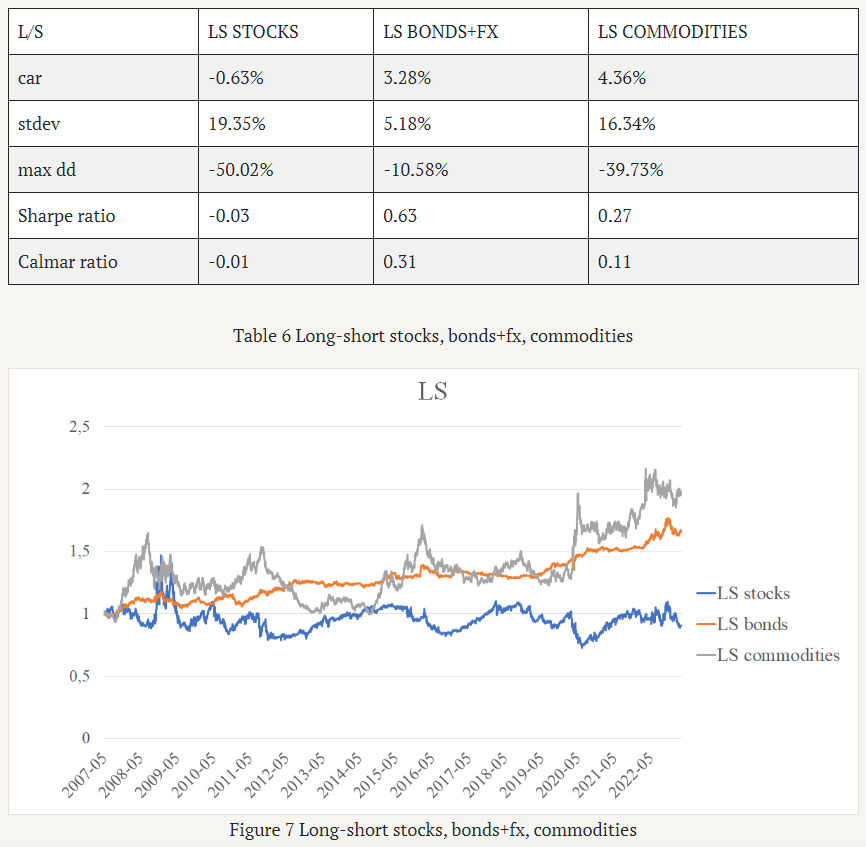

In [24]:
display.Image('./miscellaneous/cta_long_short_sub_quantpedia.png',width=600,height=100)

### Return Distribution
It is important to understand not only the direction, magnitude and drawdown of returns, but also the distribution of monthly returns. Here we present a histogram and fitted kernel density for each asset class. As one would imagine, a portfolio that consists mainly of Bonds and FXs more or less follows a normal distribution, whereas stocks and commodity portfolios tend to have fatter tails. 

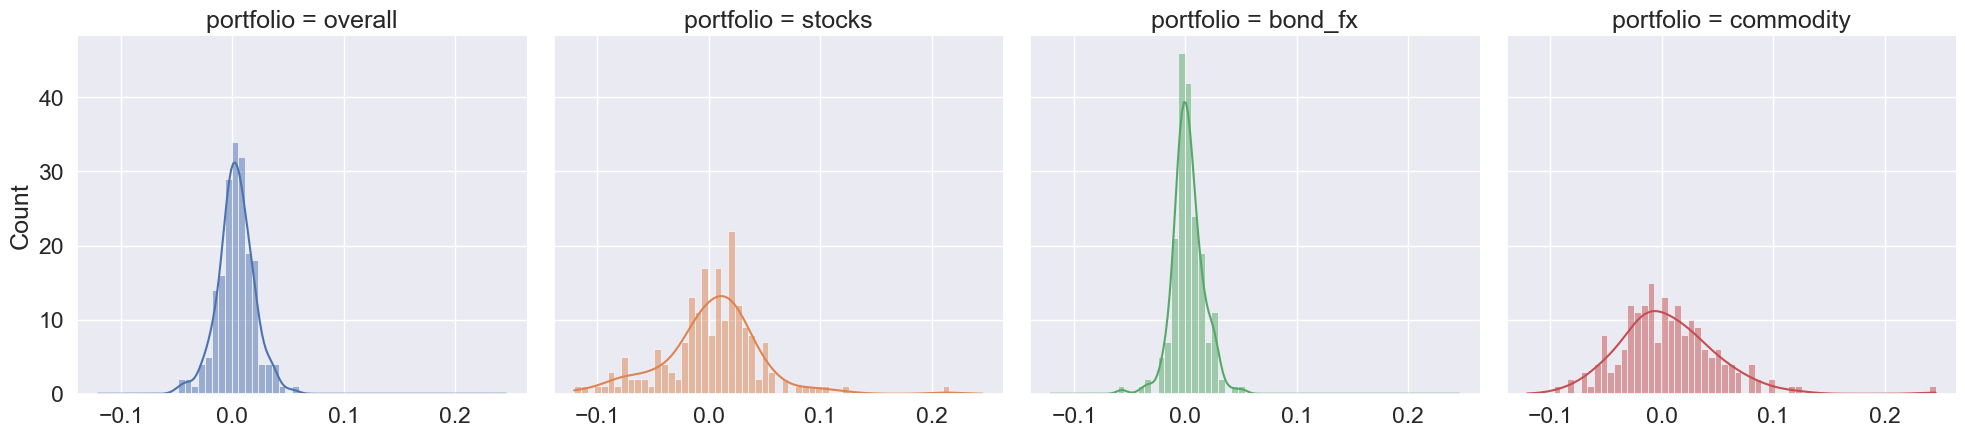

In [53]:
sns.set_style('white')
sns.set(font_scale=1.5)

return_dist = pd.DataFrame(all_return.loc[:cut_off].stack()).reset_index().rename({'level_1':'portfolio',0:'log_return'},axis=1)
sns.displot(data=return_dist, col='portfolio', x='log_return', hue='portfolio', legend=False, kde=True).set(xlabel=None)

In addition, I'm going to use a technique that I learned recently from a quant legend Mark Carhart (https://www.linkedin.com/in/mark-carhart-5b2aa62b1/) to further test out the robustness of this strategy. The execution of this technique is the following: First we re-organize the order of monthly returns based on their absolute values, and get a new time series of monthly returns. Then we take the cumulative sum of these re-ordered returns, adjust the values back to dollar returns, and plot the results. This is what you will see in the top chart below. (I also re-indexed the x-axis so that it always ranges from 0-100, which could be used to represent percentage of time) Note that you will get the same returns at the end of the time series (calendar based vs. re-ordered), but the paths to get there are different. <br>

This technique illustrates the skewness and distribution of portfolio returns. For example, we can observe that for stock portfolio, majority of the large returns in terms of magnitude is actually negative, which is what causing the stock portfolio to underperform in the long run. For instance, the stocks portfolio is outperforming all the other asset classes 70% or even 90% of the time, as the orange curve is way above other asset classes, until the tail risk kicks in (for about 10-30% of the time), and then all of sudden this portfolio is no longer attractive. Tail risk in stocks portfolio is extremely important. <br>

Another example, as you can see, commodity portfolio tends to underperform compared to other asset classes. In fact, about 90% of the time, it is not attractive, as the red curve is below other curves for majority of the time. But the tail profits are really where the magic is, putting it over the top above any other asset classes. This also demonstrates that a simple trend following strategy in commodity will lose you money for a long period before it hits, and typically the reward is sizable.

In [70]:
sort_return_dist = pd.DataFrame()

temp_return_dist = return_dist.copy()
temp_return_dist['abs_log_return'] = temp_return_dist['log_return'].abs()
temp = temp_return_dist.sort_values(['portfolio','abs_log_return'])

for i in ['overall','stocks','bond_fx','commodity']:
    temp_df = temp.loc[temp['portfolio']==i,'log_return'].copy()
    temp_df.rename(i,inplace=True)
    temp_df.reset_index(drop=True,inplace=True)
    sort_return_dist = pd.concat([sort_return_dist, temp_df], axis=1)

sort_return_dist.index = np.linspace(0, 100, len(sort_return_dist))
sort_return_dist.head(10)

,overall,stocks,bond_fx,commodity
0.000000,-0.000100,-0.001144,-0.000082,0.000065
0.529101,0.000200,-0.001399,0.000113,0.000255
1.058201,0.000271,-0.001579,-0.000144,0.000467
1.587302,-0.000552,-0.001796,0.000194,-0.000657
2.116402,0.000624,0.001814,0.000248,0.000841
2.645503,-0.000642,0.001878,0.000438,0.000921
3.174603,0.000671,-0.002050,0.000467,0.001141
3.703704,-0.000820,-0.002476,-0.000523,0.001390
4.232804,0.000845,0.002683,0.000627,0.001653
4.761905,-0.000932,0.002742,0.000751,0.001926


<Axes: xlabel='date'>

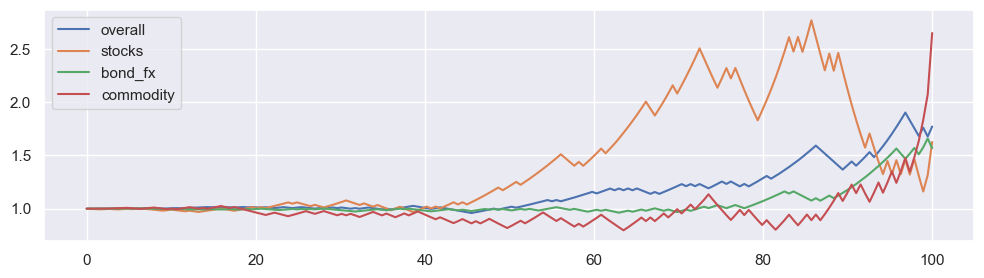

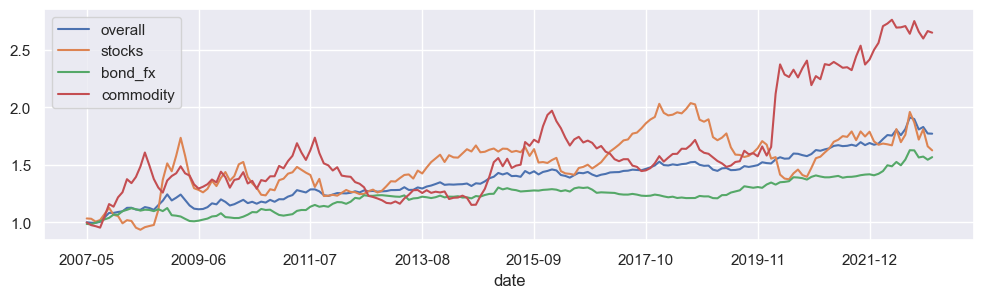

In [71]:
sns.set(font_scale=1)
np.exp(sort_return_dist.cumsum()).plot(figsize = (12,3))

np.exp(all_return.cumsum().loc[:cut_off]).plot(figsize = (12,3))